## Diffusion Models from Scratch

Sometimes it is helpful to consider the simplest possible version of something to better understand how it works. We're going to try that now, beginning with a 'toy' diffusion model to see how the different pieces work, and then examining how they differ from a more complex implementation.

We will discover:
- The corruption process (adding noise to data)
- What a UNet is, and how to implement an extremely minimal one from scratch
- Diffusion model training
- Sampling theory

Then we'll compare our version with the diffusers DDPM implementation, exploring
- Improvements over our mini UNet
- The DDPM noise schedule
- Differences in training objective
- Timestep conditioning
- Sampling approaches

In [1]:
%pip install -q diffusers

In [2]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt

if torch.backends.mps.is_available():
  device = torch.device('mps')
else:
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"-> Device used: {device}")

-> Device used: cuda


## The Data

Here we're going to test things with the `flowers 102` dataset, since I haven't seen many people using it and I think about giving it a try with the future model we are going to build!

In [3]:
train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.CenterCrop(352),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

In [4]:
dataset = torchvision.datasets.Flowers102(root='flowers102', download=True, transform=train_transforms)

In [5]:
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

Input shape: torch.Size([8, 3, 352, 352])
Labels: tensor([27, 20, 99, 21, 22, 13, 18, 80])


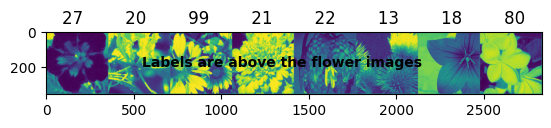

In [6]:
img, label = next(iter(train_loader))
print('Input shape:', img.shape)
print('Labels:', label)
plt.plot()
plt.title(f"{"        ".join(map(str, label.tolist()))}")
plt.annotate('Labels are above the flower images', xy=(550,200), color='black', weight='bold')
plt.imshow(torchvision.utils.make_grid(img)[0])

In [7]:
img.max(), img.min()

(tensor(2.6400), tensor(-2.1179))

Each image is a 3-channel 352x352px resized flower, with values ranging from ~-3 - 3 (due to normalization)

## The Corruption Process

Pretend you haven't read any diffusion model papers, but you know the process invoves adding noise. How would you do it?

We probably want an easy way to control the amount of corruption. So what if we take in a parameter for the `amount` of noise to add, and then we do:

`noise = torch.rand_like(x)`

`noisy_x = (1-amount)*x + amount*noise`

If amount = 0, we get back the input without any changes. If amount gets up to 1, we get back noise with no trace of the input x. By mixing the input with noise this way, we keep the output in the same range (0 to 1).

We can implement this fairly easily (**!watch the shapes so we don't get knocked out by broadcasting rules**):

In [8]:
def corrupt(x: torch.Tensor, amount, eta=1) -> torch.Tensor:
  """Corrupt the input `x` by mixing it with noise according to `amount`"""
  noise = torch.rand_like(x)
  amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
  return x*(eta-amount) + noise*amount

Looking at the results visually, we can see that this works as expected:

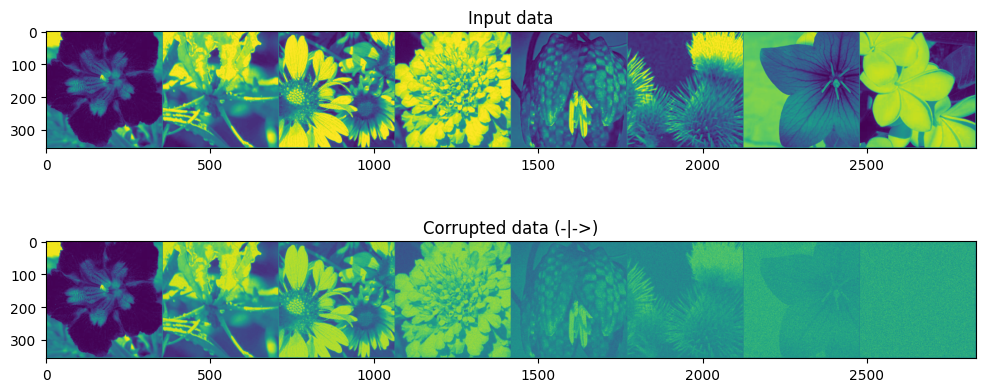

In [9]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(img)[0])

# Adding noise
amount = torch.linspace(0, 1, img.shape[0]) # Left to right -> more corruption
noised_img = corrupt(img, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data (-|->)')
axs[1].imshow(torchvision.utils.make_grid(noised_img)[0])

As we can see, as the noise amount approaches 1, our data begins to look like pure random noise.

## The Model

We'd like a model that takes in a batch of 350px noisy images and outputs predictions of the same shape. A popular choice here is an architecture called a UNet. [Originally invented for segmentation tasks in medical imagery](https://www.google.com/url?q=https%3A%2F%2Farxiv.org%2Fabs%2F1505.04597), a UNEt consists of a `'constricting path'` through which data is **compressed down** and an `'expanding path'` through which it **expands back up** to the original dimension (similar to an autoencoder) but also features skip connections that allow for information and gradients to flow across at different levels.

Some UNets feature complex blocks at each stage, but for this demo we'll build a minimal example that takes in a one-channel image and passes it through convolutional layers on the down path (the down_layers in the diagram and code) and also on the up path, with skip connections between the down and up layers.

We'll use max pooling for downsampling and `nn.Upsample` for upsampling rather than relying on learnable layers like more complex UNets. Here is the rough architecture showing the number of channels in the output of each layer:


~Generate image here~

This is what it looks like in code:

In [10]:
import torch.nn as nn

class BasicUNet(nn.Module):
  """A minimal UNet implementation."""
  def __init__(self, in_channels=3, out_channels=3):
    super().__init__()
    self.down_layers = nn.ModuleList([
        nn.Conv2d(in_channels, 64, kernel_size=5, padding=2),
        nn.Conv2d(64, 128, kernel_size=5, padding=2),
        nn.Conv2d(128, 256, kernel_size=5, padding=2),
    ])

    self.down_norms = nn.ModuleList([
        nn.BatchNorm2d(64),
        nn.BatchNorm2d(128),
        nn.BatchNorm2d(256),
    ])

    self.up_layers = nn.ModuleList([
        nn.Conv2d(256, 128, kernel_size=5, padding=2),
        nn.Conv2d(128 + 128, 64, kernel_size=5, padding=2), # 128 (up) + 128 (skip)
        nn.Conv2d(64 + 64, out_channels, kernel_size=5, padding=2), # 64 (up) + 64 (skip)
    ])

    # We don't normalize the first up convolution layer, because it is normalized indirectly the moment it enters the loop, due to the skip connection
    self.up_norms = nn.ModuleList([
        nn.BatchNorm2d(128),
        nn.BatchNorm2d(64),
    ])

    self.gelu = nn.GELU() # Activation function
    self.downscale = nn.MaxPool2d(2) # Output -> [B, C, H/2, W/2]
    self.upscale = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) # Expects [B, C, H, W]; Increases the spatial dimensions (H & W) of an input tensor. --> typically used in neural networks to resize low-resolution feature maps into higher-resolution ones (e.g., in architectures like U-Net for segmentation or GANs for generating images).

  def forward(self, x):
    h = [] # Intermediary list
    # --- ENCODER ---
    for i, l in enumerate(self.down_layers):
      out = self.gelu(self.down_norms[i](l(x))) # Pass through the 'l' layer and the activation function
      x = out + x if x.shape == out.shape else out # if channel dimensions match, we adjust the gradient flowing pathways

      if i < 2: # For all but the third (final) down layer:
        h.append(x) # Storing output for skip connection
        x = self.downscale(x) # Downscale ready for the next layer

    for i, l in enumerate(self.up_layers):
      if i > 0: # For all except the first up layer
        x = self.upscale(x) # Upscale
        skip_connection = h.pop()
        x = torch.cat([x, skip_connection], dim=1) # Concatenate but we could also have done addition (x += h.pop())

      if i == len(self.up_layers) - 1:
        x = l(x) # Exit w/o GELU
      else:
        x = self.gelu(self.up_norms[i](l(x))) # Pass through the 'l' layer and the activation function

    return x

We can verify that the output shape is the same as the input, as we expect:

In [11]:
net = BasicUNet()
x = torch.rand(8, 3, 28, 28)
net(x).shape

torch.Size([8, 3, 28, 28])

This network has just over 350,000 parameters:

In [12]:
sum(p.numel() for p in net.parameters())

2269123

## Training the network

So what should the model do, exactly? Again, there are various takes on this but for the demo we will pick a simple framing: given a corrputed input noisy_x the model should output its best guess for what the original x looks like. We will compare this to the actual value via the mean squared error.

We can now have a go at training the network.
- Get a batch of data
- Corrupt it by random amounts
- Feed it through the model
- Compare the model predictions with the clean images to calculate our loss
- Update the model's parameters accordingly

Feel free to modify also this section!

In [13]:
#[p for p in net.parameters() if p.ndim != 2]

Epoch Finished -> 0. Average loss for this epoch: 0.450087
Epoch Finished -> 1. Average loss for this epoch: 0.257706
Epoch Finished -> 2. Average loss for this epoch: 0.254404
Epoch Finished -> 3. Average loss for this epoch: 0.240934
Epoch Finished -> 4. Average loss for this epoch: 0.247301
Epoch Finished -> 5. Average loss for this epoch: 0.216525
Epoch Finished -> 6. Average loss for this epoch: 0.198409
Epoch Finished -> 7. Average loss for this epoch: 0.188619
Epoch Finished -> 8. Average loss for this epoch: 0.197336
Epoch Finished -> 9. Average loss for this epoch: 0.187666
Epoch Finished -> 10. Average loss for this epoch: 0.208514
Epoch Finished -> 11. Average loss for this epoch: 0.184175
Epoch Finished -> 12. Average loss for this epoch: 0.162629
Epoch Finished -> 13. Average loss for this epoch: 0.183561
Epoch Finished -> 14. Average loss for this epoch: 0.154972
Epoch Finished -> 15. Average loss for this epoch: 0.163885
Epoch Finished -> 16. Average loss for this epoch:

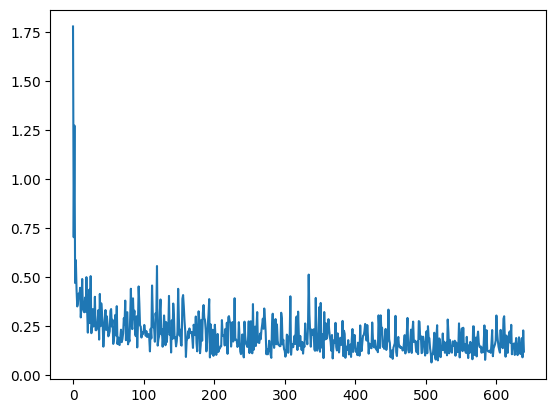

In [18]:
# Dataloader
batch_size=32
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

n_epochs=20

# Create the network
net = BasicUNet()
net.to(device)

# Our loss function
crit = nn.MSELoss()

# The optimizer settings
optim = torch.optim.AdamW(net.parameters(), lr=1e-3)

# A list of losses for viewing
loss_l = []

# Training loop
for epoch in range(n_epochs):
  for img, label in train_loader:
    img = img.to(device) # Data on the GPU/MPS
    noise_amount = torch.rand(img.shape[0]).to(device) # Pick random noise amounts
    noisy_img = corrupt(img, noise_amount) # Create our noisy x

    # Get the model prediction
    pred = net(noisy_img)

    # Calculate the loss
    loss = crit(pred, img) # How close is the output to the true 'clean' x?

    # Backprop
    optim.zero_grad()
    loss.backward()
    optim.step()

    # Store the loss for later
    loss_l.append(loss.item())

  # Print our average of the loss values for the epoch:
  avg_loss = sum(loss_l[-len(train_loader):]) / len(train_loader)
  print(f"Epoch Finished -> {epoch}. Average loss for this epoch: {avg_loss:05f}")

# View the loss curve
plt.plot(loss_l)
#plt.ylim(0, 0.1);

We can try to see what the model predictions look like by grabbing a batch of data, corrupting it by different amounts and then seeing the models predictions:

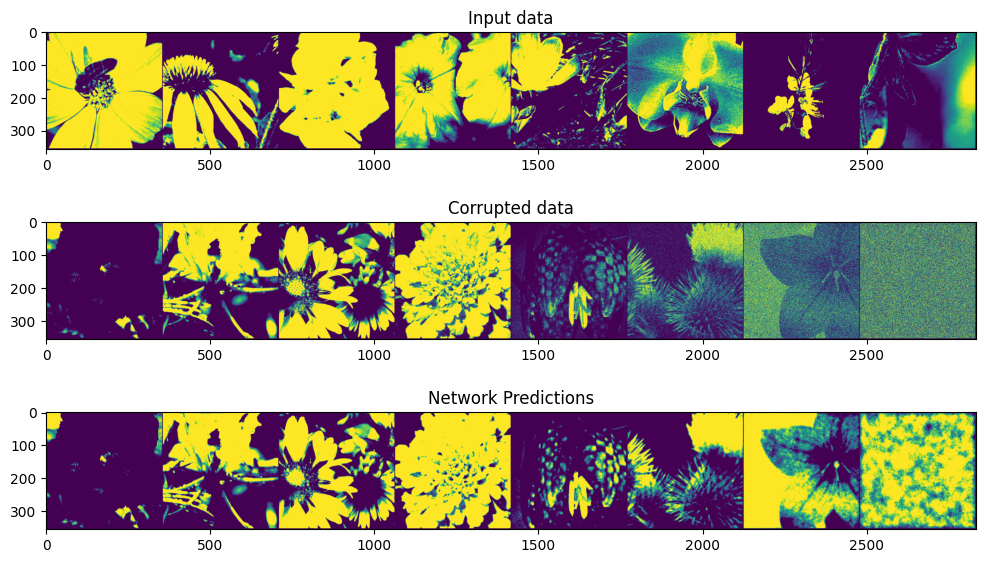

In [19]:
#@markdown Visualizing model predictions on noisy inputs:

# Fetch some data
img, label = next(iter(train_loader))
img = img[:8] # Only using the first 8 for easy plotting

# Corrupt with a range of amounts
amount = torch.linspace(0, 1, img.shape[0]) # Left to right -> more corruption
noises_img = corrupt(img, amount)

# Get the model predictions
with torch.no_grad():
  preds = net(noised_img.to(device)).detach().cpu()

# Plot
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 7))
ax0.set_title('Input data')
ax0.imshow(torchvision.utils.make_grid(img)[0].clip(0, 1))
ax1.set_title('Corrupted data')
ax1.imshow(torchvision.utils.make_grid(noised_img)[0].clip(0, 1))
ax2.set_title('Network Predictions')
ax2.imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1))

We can see that for the lower amounts the predictions are pretty good! But as the level gets very high there is less for the model to work with, and by the time we get to amount=1 it outputs a blurry mess close to the mean of the dataset to try and hedge its bets on what the output might look like...

## Sampling

When `"playing"` with diffusion models, a common question arises: Considering that our predictions at high noise levels aren't very good, how do we generate images then?

Well, what if we start from random noise, look at the model predictions but then only move a small amount towards that predictions - say, `20%` of the way there. Now we have a very noisy image in which there is perhaps a hint of structure, which we can feed into the model to get a new prediction. The hope is that this new prediction is slightly better than the first one (since our starting point is slightly less noisy) and so we can take another small step with this new, better prediction.

Repeat a few times and (if all goes well) we get an image out! Here is that process illustrated over just 5 steps, visualizing the model input (left) and the predicted denoised images (right) at each stage. Note that even though the model predicts the denoised image even at step 1, we only move x part of the way there. Over a few steps the structures appear and are refined, until we get our final outputs.

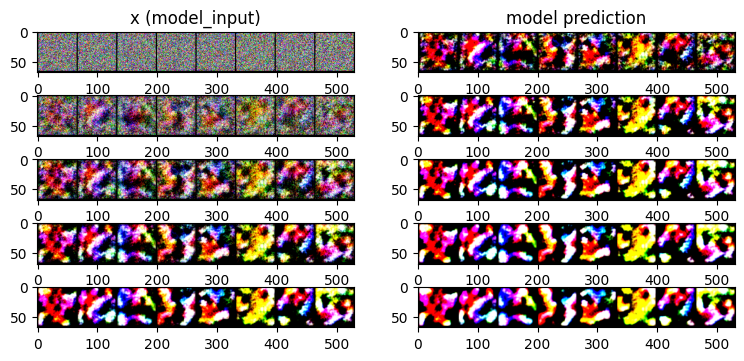

In [23]:
#@markdown Sampling strategy: Break the process into 5 steps and move 1/5'th of the way there each time:
n_steps=5
x = torch.rand(8, 3, 64, 64).to(device) # Start from random noise
step_hist = [x.detach().cpu()]
pred_output_hist = []

for i in range(n_steps):
  with torch.no_grad(): # No need to track gradients during inference
    pred = net(x) # Predict the denoised x_0
  pred_output_hist.append(pred.detach().cpu()) # Store model output for plotting
  mix_factor = 1/(n_steps - i) # How much we move towards the prediction
  x = x*(1-mix_factor) + pred*mix_factor # Move part of the way there
  step_hist.append(x.detach().cpu())

fig, axs = plt.subplots(n_steps, 2, figsize=(9, 4))
axs[0,0].set_title('x (model_input)')
axs[0,1].set_title('model prediction')
for i in range(n_steps):
  grid_step = torchvision.utils.make_grid(step_hist[i]).clip(0, 1)
  axs[i,0].imshow(grid_step.permute(1, 2, 0).detach().cpu().numpy())
  grid_pred = torchvision.utils.make_grid(pred_output_hist[i]).clip(0, 1)
  axs[i,1].imshow(grid_pred.permute(1, 2, 0).detach().cpu().numpy())


We can split the process up into more steps and hope for better images that way, but, the model is too weak/doesn't generalize well on our Flower dataset as you can see:

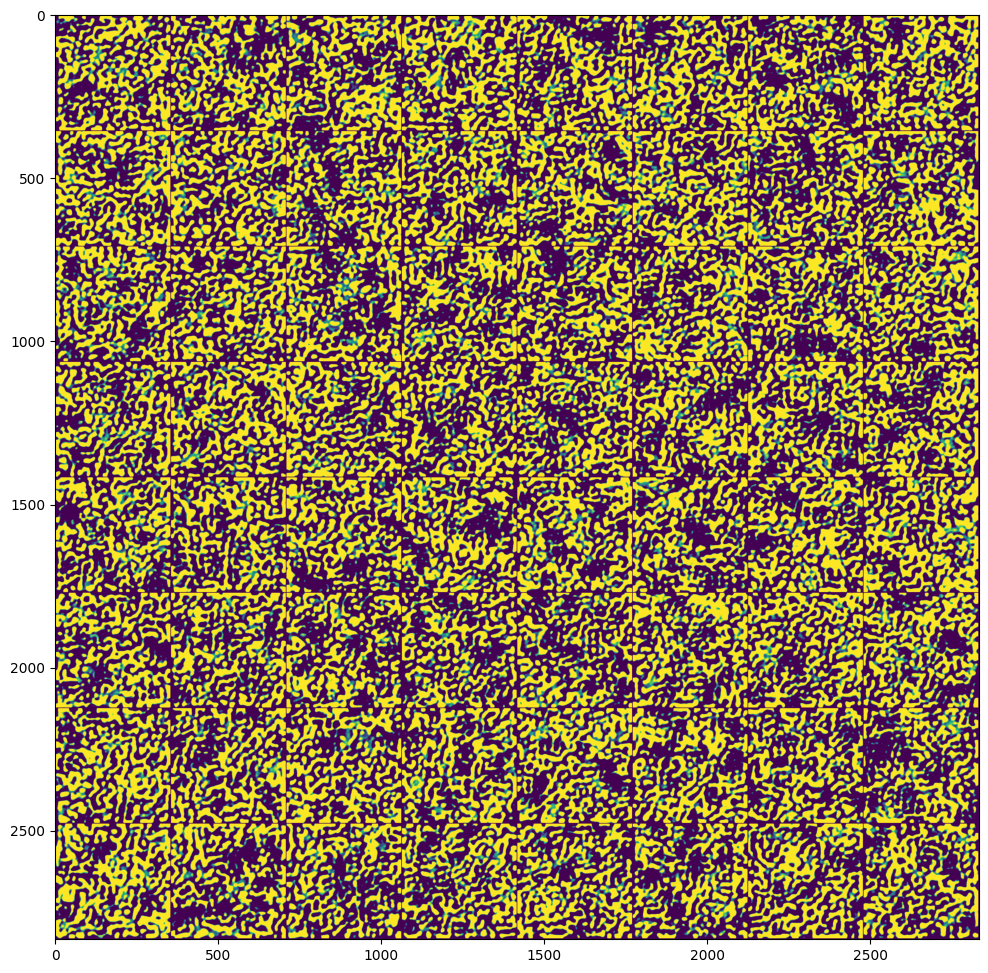

In [38]:
#@markdown Showing more results, using 40 sampling steps
n_steps=250
x = torch.rand(64, 3, 352, 352).to(device)
for i in range(n_steps):
  noise_amount = torch.ones((x.shape[0], )).to(device) * (1-(i/n_steps)) # Starting high going low
  with torch.no_grad():
    pred = net(x)
  mix_factor = 1/(n_steps - i)
  x = x*(1-mix_factor) + pred*mix_factor
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1))

You can also experiment with training the model for a much higher number of epochs and tweaking the config, lr, optimizer, and so on.

## Comparison to DDPM
In this section we'll take a look at how our toy implementation differs from the approach used in the first notebook, which is based on the DDPM paper.

We'll see that:
- The diffusers `UNet2DModel` is a bit more advanced than our BasicUNet
- The corruption process is handles differently
- The training objective is different, involving predicting the noise rather than the denoised image
- The model is conditioned on the amount of noise present via timestep conditioning, where `t` is passed as an additional argument to the forward method.
- There are a number of different sampling strategies available, which should work better than our simplistic version above.

## The UNet

The diffusers `UNet2DModel` has a number of improvements over our basic PyTorch UNet above:
- Dropout layers for smoother training
- Multiple resnet layers per block
- Attention (usually used only at lower resolution blocks)
- Conditioning on the timestep
- Downsampling and upsampling blocks w/ learable parameters

Let's create and inspect a `UNet2DModel`:

In [ ]:
model = UNet2DModel(
    sample_size=28, # the target image res.
    in_channels=3, # the number of input channels
    out_channels=3, # the number of output channels
    layers_per_block=2, # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 64), # Roughly matching our basic unet example
    down_block_types=(
        'DownBlock2D', # a regular ResNet downsampling block
        'AttnDownBlock2D', # a ResNet downsampling block w/ spatial self-attention
        'AttnDownBlock2D',
    ),
    up_block_types=(
        'AttnUpBlock2D',
        'AttnUpBlock2D', # a ResNet upsampling block w/ spatial self-attention
        'UpBlock2D', # a regular ResNet upsampling block
    ),
)
print(model)

In [ ]:
"""Parameter count also for this model"""
sum([p.numel() for p in model.parameters()])

### The Corruption Process

The DDPM paper describes a corruption process that adds a small amount of noise for every 'timestep'. Given $x_{t-1}$ for some timestep, we can get the next (slightly more noisy) version $x_t$ with:<br><br>

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$<br><br>


That is, we take $x_{t-1}$, scale it by $\sqrt{1 - \beta_t}$ and add noise scaled by $\beta_t$. This $\beta$ is defined for every t according to some schedule, and determines how much noise is added per timestep. Now, we don't necessarily want to do this operation 500 times to get $x_{500}$ so we have another formula to get $x_t$ for any t given $x_0$: <br><br>

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, \sqrt{(1 - \bar{\alpha}_t)} \mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$ and $\alpha_i = 1-\beta_i$<br><br>

The maths notation always looks scary! Luckily the scheduler handles all that for us (uncomment the next cell to check out the code). We can plot $\sqrt{\bar{\alpha}_t}$ (labelled as `sqrt_alpha_prod`) and $\sqrt{(1 - \bar{\alpha}_t)}$ (labelled as `sqrt_one_minus_alpha_prod`) to view how the input (x) and the noise are scaled and mixed across different timesteps:


In [ ]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
plt.plot(noise_scheduler.alphas_cumprod.cpu()**0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu())**0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

Initially, the noisy x is mostly x (sqrt_alpha_prod ~= 1), but over time the contribution of x drops and the noise component increases. Unlike our linear mix of x and noise according to `amount`, this one gets noisy relatively quickly. We can visualize this on some data:

In [ ]:
#@markdown visualize the DDPM noising process for different timesteps:

# Noise a batch of images to view the effect
fig, axs = plt.subplots(3, 1, figsize=(16, 10))
xb, yb = next(iter(train_loader))
xb = xb.to(device)[:8]
xb = xb * 2. - 1. # Map to (-1, 1)
print('X shape', xb.shape)

# Show clean inputs
axs[0].imshow(torchvision.utils.make_grid(xb[:8])[0].detach().cpu())
axs[0].set_title('Clean X')

# Add noise with scheduler
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb) # << NB: randn not rand
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print('Noisy X shape', noisy_xb.shape)

# Show noisy version (w/ and w/o clipping)
axs[1].imshow(torchvision.utils.make_grid(noisy_xb[:8])[0].detach().cpu().clip(-1, 1))
axs[1].set_title('Noisy X (clipped to (-1, 1)')
axs[2].imshow(torchvision.utils.make_grid(noisy_xb[:8])[0].detach().cpu())
axs[2].set_title('Noisy X')

Another dynamic at play: the DDPL version adds noise drawn from a Gaussian distribution (mean 0, std 1 from torch.randn) rather than the uniform noise between 0 and 1 (from torch.rand) we used in our original `corrupt` function. In general, it makes sense to normalize the training data as well. In the other notebooks, we'll use `Normalize(0.5, 0.5)` in the list of transforms, which maps the image data from (0, 1) to (-1, 1) and is 'good enough' for our purposes.

## Timestep Conditioning

The `UNet2DModel` takes in both x and timestep. The latter is turned into an embedding and fed into the model in a number of places.

The theory behind that is that by giving the model information about what the noise level is, it can better perform its task. While it is possible to train a model without this timestep conditioning, it does seem to help performance in some cases and most implementations include it, at least in the current literature.

## Sampling

Given a model that estimates the noise present in a noisy input (or predicts the denoised version), how do we produce new images?

We could feed in **pure noise**, and hope that the model predicts a good image as the denoised version in one step. However, as we saw in the experiments above, this doesn't usually work well. So, instead, we take a number of smaller steps based on the model prediction, iteratively removing a little bit of the noise at a time.

Exactly how we take these steps depends on the sampling method used. We won't go into the theory too deeply, but some key desing questions are:
- How large of a step should you take? In other words, what 'noise schedule' should you follow?
- Do you use only the model's current prediction to inform the update step (like DDPM, DDIM and many others)? Do you evaluate the model several times to estimate higher-order gradients for a larger, more accurate step (higher-order methods and some discrete ODE solvers)? Or do you keep a history of past predictions to try an better inform the current update step (linear multi-step and ancestral samplers)?
- Do you add in additional noise (sometimes called churn) to add more stochasticity to the sampling process, or do you keep it completely deterministic? Many samplers control this w/ a parameter (such as η (eta) for DDIM samplers) so that the user can choose.

Research on sampling methods for diffusion models is rapidly evolving, and more and more methods for finding good solutions in fewer steps are being proposed.

## Conclusions

Hopefully,, this has been a helpful and creative exploratory way to discover diffusion models from a slighly different angle.

This notebook was written for the Hugging Face diffusions course by Jonathan Whitaker, and adapted by **Pop Alexandru** ([pop123ux](https://github.com/pop123-ux))

You are also welcome to reach out to him via Twitter [@johnowhitaker](https://x.com/johnowhitaker).